In [1]:
from PIL import Image
import numpy as np
import os
import sys

sys.path.append("/home/alberto/UnReflectAnything/")
from utilities.visualization import rgb, panelize
import torch
from dataset.rgbp import POLARGB_Dataset
from rich import print
%load_ext autoreload
%autoreload 2    


In [4]:

dataset = POLARGB_Dataset(
        root_dir="/datasets/PolaRGB/",
        polarization_format="separate_files",
        target_size=[224,224],
        exclude="test",
        rho_s=0.6,
        eps=1e-8
    )
    
# Create dataloader
dataloader = torch.utils.data.DataLoader(dataset, batch_size=1, shuffle=True)
idataloade = iter(dataloader)

# Test loading a batch
for batch in dataloader:
    # print("Batch shapes:")
    for key, tensor in batch.items():
        print(f"  {key}: {tensor.shape}")  # All will be [B, C, H, W]

    
    break

# rgb(batch["rgb"][0],colormap="hsv")


/home/alberto/UnReflectAnything/dataset/rgbp.py:362: UserWarning: Could not load intrinsics from None: fname must be a string, filehandle, list of strings,
or generator. Got <class 'NoneType'> instead.
  warnings.warn(f"Could not load intrinsics from {intrinsics_path}: {e}")


I0: torch.Size([1, 3, 224, 224])

I45: torch.Size([1, 3, 224, 224])

I90: torch.Size([1, 3, 224, 224])

I135: torch.Size([1, 3, 224, 224])

...

f_spec: torch.Size([1, 1, 224, 224])

rgb: torch.Size([1, 3, 224, 224])

specular: torch.Size([1, 3, 224, 224])

diffuse: torch.Size([1, 3, 224, 224])

intrinsics: torch.Size([1, 3, 3])

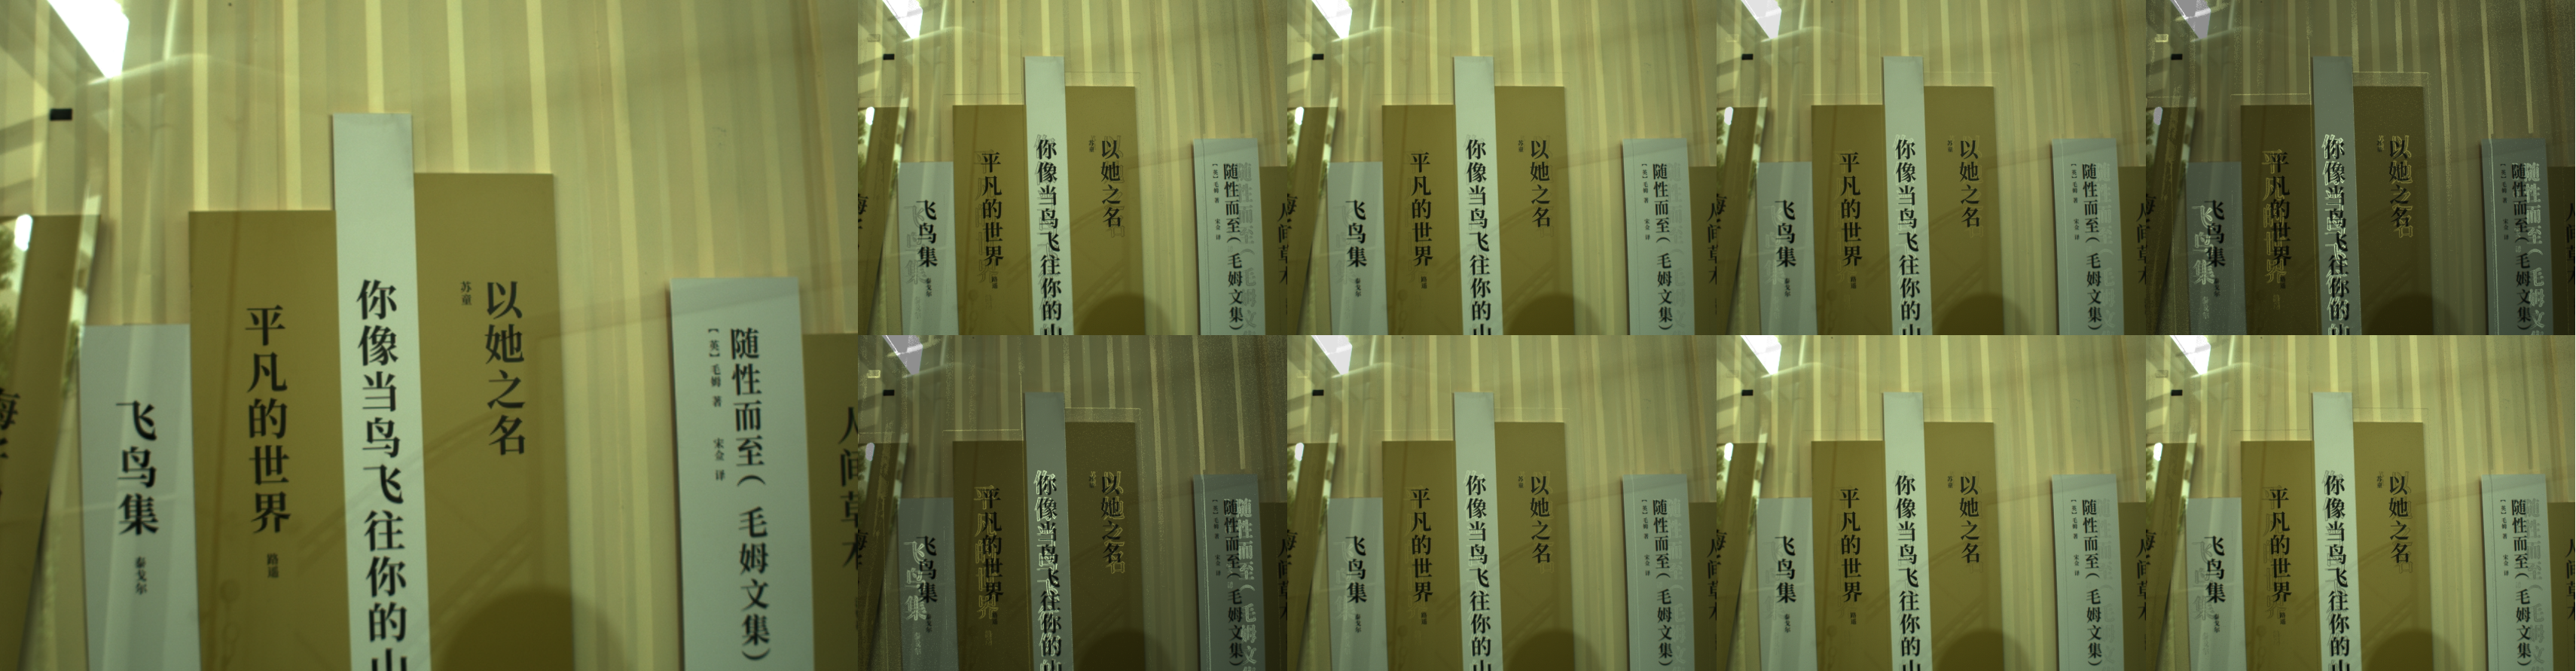

In [12]:
rgb(
    panelize(
        rgb(
            batch["rgb"][0],
            as_tensor=True,
            resize=(892, 1140),
            colormap="gray",
        ),
        panelize(
        panelize(
            rgb(
                0.2 * batch["specular"][0] + 0.8 * batch["diffuse"][0],
                as_tensor=True,
                resize=(892 // 2, 1140 // 2),
            ),
            rgb(
                0.4 * batch["specular"][0] + 0.6 * batch["diffuse"][0],
                as_tensor=True,
                resize=(892 // 2, 1140 // 2),
            ),
            rgb(
                0.6 * batch["specular"][0] + 0.4 * batch["diffuse"][0],
                as_tensor=True,
                resize=(892 // 2, 1140 // 2),
            ),
            rgb(
                0.8 * batch["specular"][0] + 0.2 * batch["diffuse"][0],
                as_tensor=True,
                resize=(892 // 2, 1140 // 2),
            ),
        ),
        panelize(
            rgb(
                0.8 * batch["specular"][0] + 0.2 * batch["diffuse"][0],
                as_tensor=True,
                resize=(892 // 2, 1140 // 2),
            ),
            rgb(
                0.6 * batch["specular"][0] + 0.4 * batch["diffuse"][0],
                as_tensor=True,
                resize=(892 // 2, 1140 // 2),
            ),
            rgb(
                0.4 * batch["specular"][0] + 0.6 * batch["diffuse"][0],
                as_tensor=True,
                resize=(892 // 2, 1140 // 2),
            ),
            rgb(
                0.2 * batch["specular"][0] + 0.8 * batch["diffuse"][0],
                as_tensor=True,
                resize=(892 // 2, 1140 // 2),
            ),
        ),
        mode="vertical"),
        resize_to_match=False
    )
)

In [ ]:
from projections import ReflectionWarp
from dotmap import DotMap
import yaml

# Initialize the module
height, width = batch["rgb"].shape[2:]
reflection_warp = ReflectionWarp(height, width)
reflection_warp = reflection_warp.cuda()  # Move to GPU


light_color = torch.tensor([1.0, 0.8, 0.8]).cuda()  # Warm light

from pipelines.depth.depth import DepthPipeline

CONFIG_PATH = "../config.yaml"
with open(CONFIG_PATH, "r") as f:
    config_yaml = yaml.safe_load(f)
    config_parameters = config_yaml["parameters"]
    config_training_dict = {
        k: v.get("value") for k, v in config_parameters.items() if v is not None
    }
    config = DotMap(config_training_dict)
    config.IMAGE_HEIGHT = height
    config.IMAGE_WIDTH = width
depthPipeline = DepthPipeline(config, model="", device="cuda")

light_position = torch.randn((1,3))*config.DEPTH_SCALE_FACTOR/2
light_position[0,1:] = -torch.abs(light_position[0,1:])
torch.cuda.empty_cache()
with torch.no_grad():
    depth_map = depthPipeline.depth(batch["rgb"].cuda())

# Call with point light
result = reflection_warp.forward_point_light(
    source_image=batch["rgb"][0:1].cuda(),
    depth_map=depth_map[0:1].cuda(),
    camera_intrinsics=batch["intrinsics"].cuda()[0:1],
    camera_pose=torch.eye(4)
    .unsqueeze(0)
    .repeat(batch["rgb"].shape[0], 1, 1)
    .cuda()[0:1],
    light_position=light_position.cuda(),
    light_intensity=100.0,
    light_color=light_color.cuda(),
    surface_roughness=0.1,  # Slightly rough surface
    reflection_strength=0.9,  # Strong reflections
    return_mask=True,
    return_artifacts=True,
)
rgb(
    panelize(
        rgb(result["warped"][0], as_tensor=True),
        rgb(result["reflection_only"][0], colormap="gray", as_tensor=True),
        rgb(batch["rgb"][0], as_tensor=True),
    )
)

In [ ]:
result.keys()

In [ ]:
batch["rgb"].shape,depth_map.shape, batch["intrinsics"].shape,torch.eye(4).unsqueeze(0).repeat(batch["rgb"].shape[0],1,1).cuda().shape

In [ ]:
result = reflection_warp.forward_point_light(
    source_image=batch["rgb"][0:1].cuda(),
    depth_map=depth_map[0:1].cuda(),
    camera_intrinsics=batch["intrinsics"].cuda()[0:1],
    camera_pose=torch.eye(4)
    .unsqueeze(0)
    .repeat(batch["rgb"].shape[0], 1, 1)
    .cuda()[0:1],
    light_position=light_position.cuda(),
    light_intensity=100.0,
    light_color=light_color.cuda(),
    surface_roughness=0.1,  # Slightly rough surface
    reflection_strength=0.9,  # Strong reflections
    return_mask=True,
    return_artifacts=True,
)

In [ ]:
rgb(batch["rgb"][0])
rgb(depth_map[0],colormap="jet")